In [103]:
import os
import torch
import sys
import matplotlib.pyplot as plt
from gsplat import rasterization
from optical.surface_2 import WaterSurface
from optical.surface_2 import TransformWaterSurface
from optical.utils.test_utils import LoadDataset
from optical.utils.test_utils import combert_into_colormap, compare_rasterization_variants, np_rgb_render

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [104]:
# Dataset = LoadDataset()
Dataset = LoadDataset(wo_ref_model_path="../../results/0610/☆2025-0612_23-09_refraction_previous_default/ply/point_cloud_14999.ply")
Dataset.set_iamge(80)

means, scales, quats, opacities, colors = Dataset.get_model_param()
pixels_wo, pixels_w, camtoworld, worldtocam, cam_center, K, height, width, image_id = Dataset.get_camera_param()

Loading 3D point cloud from: /home/taiki/dataset/river2/wo_refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/wo_refraction.
Loading 3D point cloud from: /home/taiki/dataset/river2/refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/refraction.


In [105]:
# Setting Refraction Parameters
n = 1.33
plane = 0.0
num_newton_iters = 10
newton_atol = 1e-6

WS = WaterSurface(
    means=means,
    quats=quats,
    scales=scales,
    cam_center=cam_center,
    n=n,
    plane=plane,
)


In [106]:

t_means = WS.transform_means()
# dPa_dP = WS.calc_dPa_dP()
dPa_dP = WS.calc_dPa_dP_with_minibatches()
t_quats = WS.transform_quats()
t_scales_volume_dev3 = WS.transform_scales(
    method_transform_scales="volume",
    coeff_transform_scales=1/3,
    scale_correct_space="real"
)
t_scales_volume_dev2 = WS.transform_scales(
    method_transform_scales="volume",
    coeff_transform_scales=1/2,
    scale_correct_space="real"
)
t_scales_edges_dev3 = WS.transform_scales(
    method_transform_scales="edges",
    coeff_transform_scales=1/3,
    scale_correct_space="real"
)
t_scales_edges_dev2 = WS.transform_scales(
    method_transform_scales="edges",
    coeff_transform_scales=1/2,
    scale_correct_space="real"
)

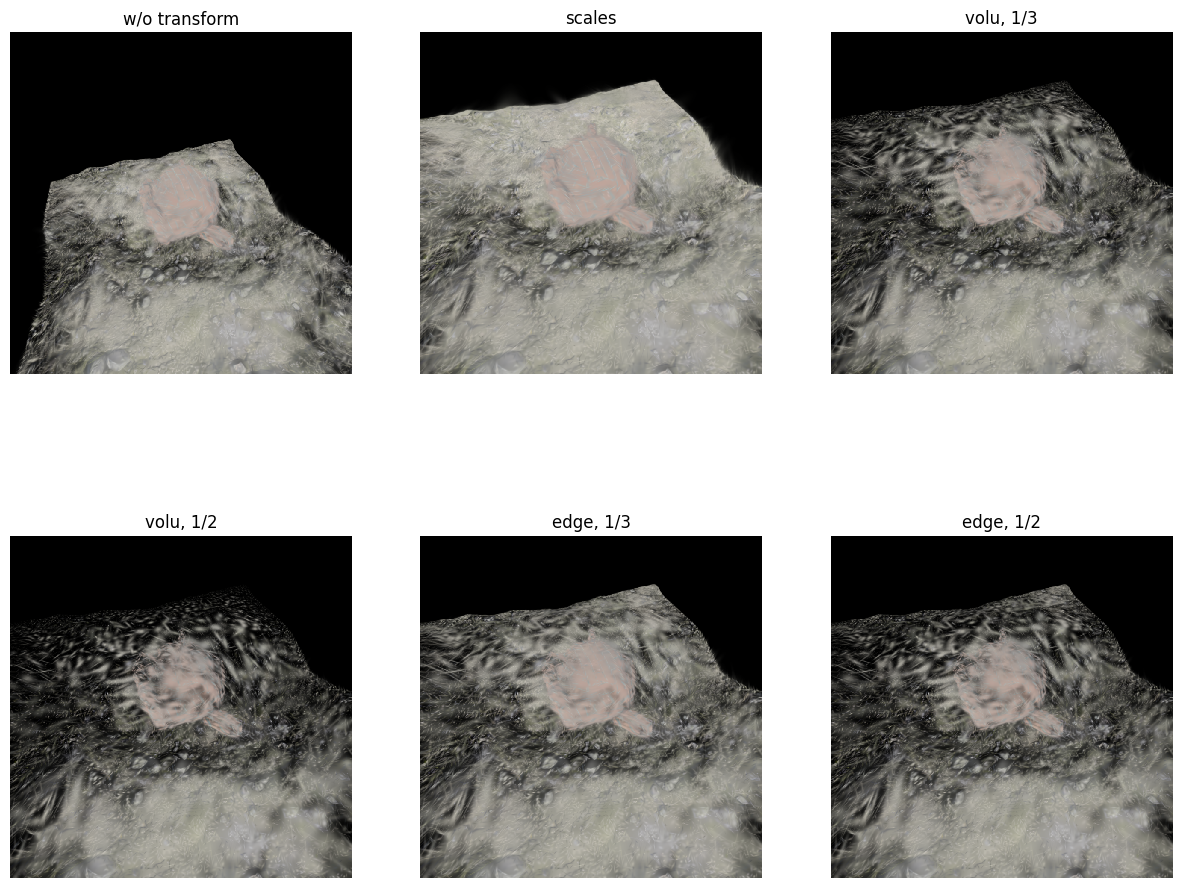

In [107]:
dict_t_scales = {
    "w/o transform":scales, 
    "scales": scales,
    "volu, 1/3": t_scales_volume_dev3,
    "volu, 1/2": t_scales_volume_dev2,
    "edge, 1/3": t_scales_edges_dev3,
    "edge, 1/2": t_scales_edges_dev2  
}

fig, axes = plt.subplots(2,3)
axes = axes.flatten()
for idx, (title_str, t_scales) in enumerate(dict_t_scales.items()):
    m = means if idx == 0 else t_means 
    render, _, _ = rasterization(
        m,
        t_quats,
        t_scales,
        opacities,
        colors,
        worldtocam,
        K,
        width,
        height,
        sh_degree=0,
        rasterize_mode="antialiased"
    )

    render_np = render.squeeze().cpu().detach().numpy()
    axes[idx].imshow(render_np)
    axes[idx].axis('off')
    axes[idx].set_title(title_str)
    
plt.show()

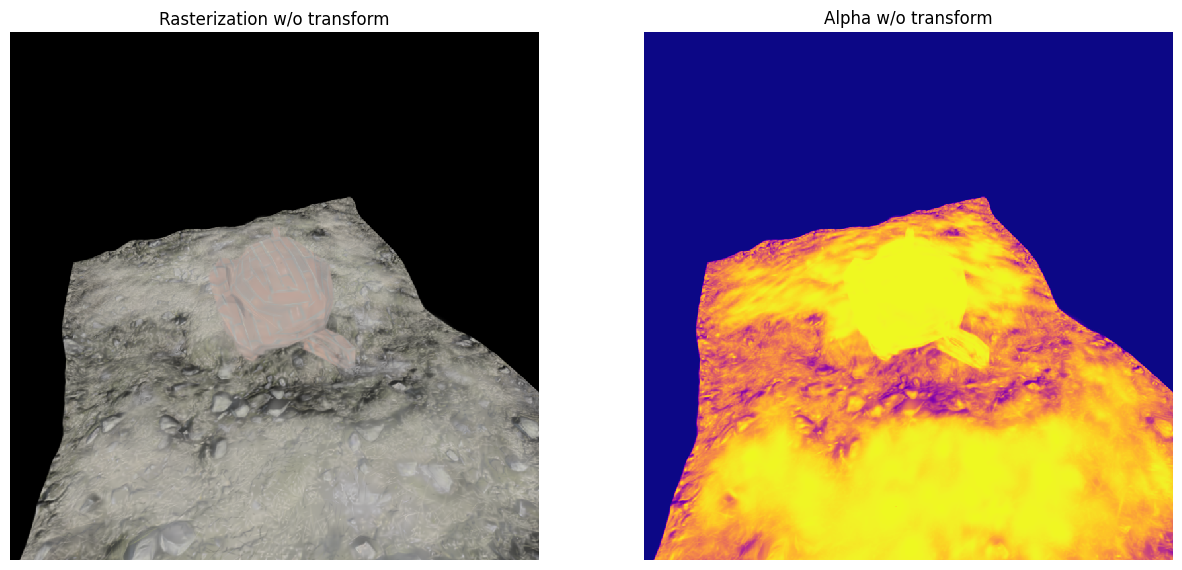

In [108]:
render_wo, alpha_wo, _ = rasterization(
    means,
    quats,
    scales,
    opacities,
    colors,
    worldtocam,
    K,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)

render_wo = render_wo.squeeze().cpu().detach().numpy()
alpha_wo = alpha_wo.squeeze().cpu().detach().numpy()

fig, axes = plt.subplots(1, 2)
axes[0].imshow(render_wo)
axes[0].axis('off')
axes[0].set_title("Rasterization w/o transform")
axes[1].imshow(alpha_wo, cmap='plasma')
axes[1].axis('off')
axes[1].set_title("Alpha w/o transform")
plt.show()


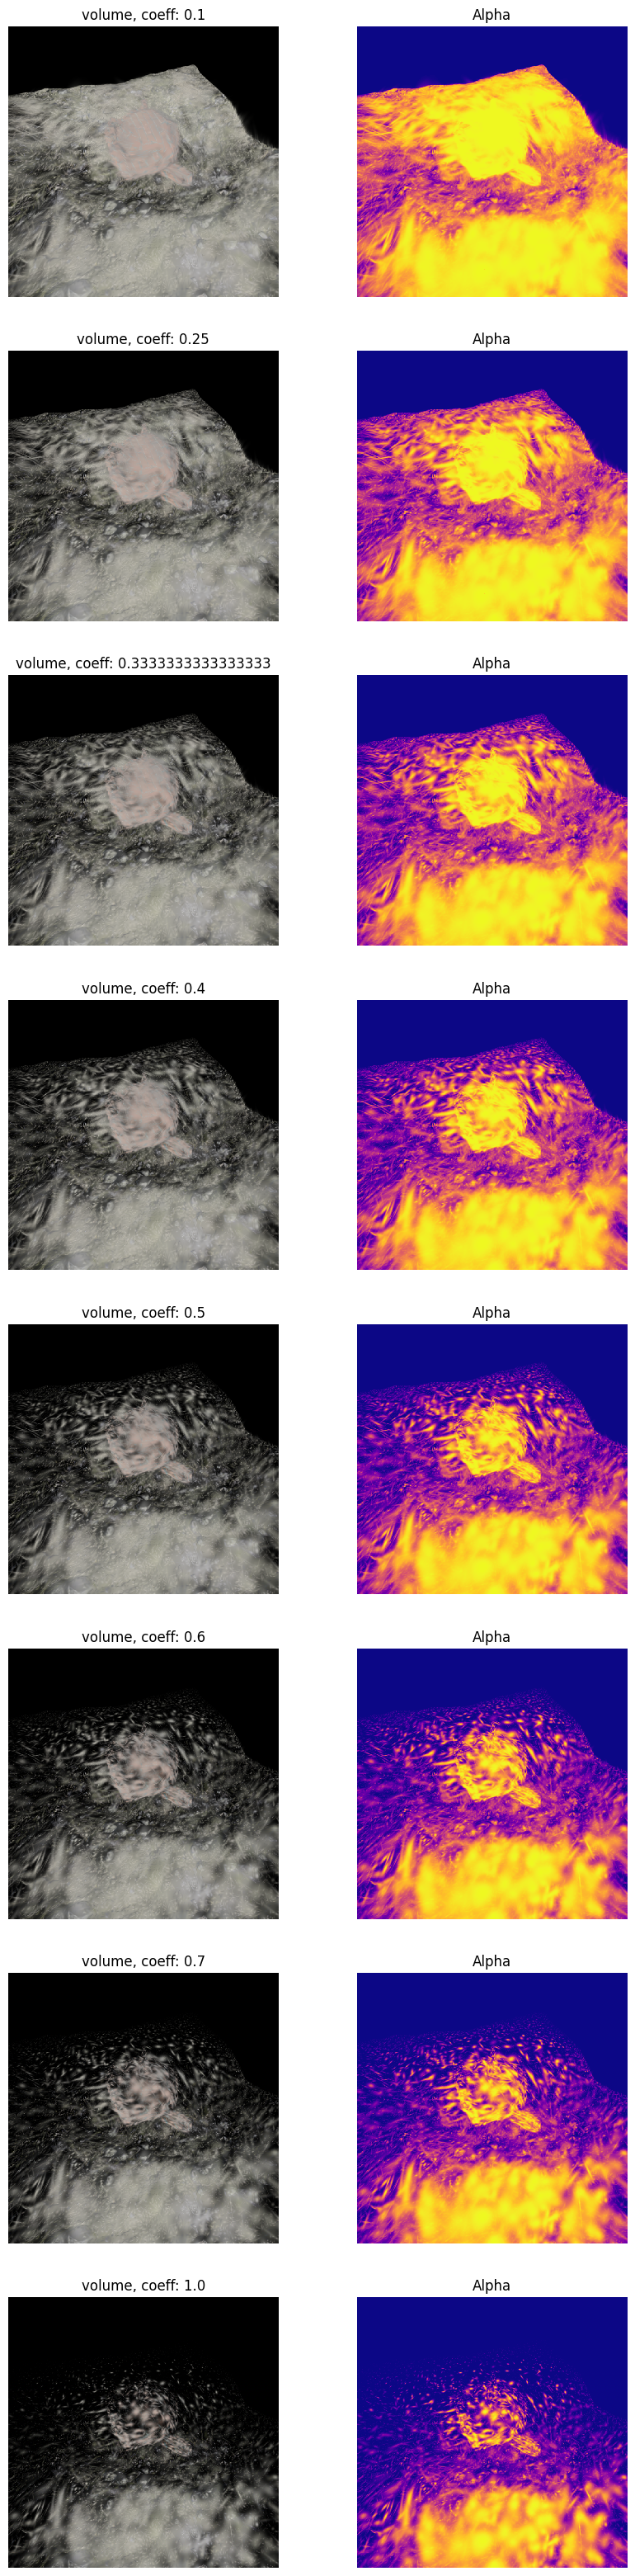

In [109]:
param = {
    "method": "volume",
    "coeff": 1.0,
}

list_coeff = [0.1, 1/4, 1/3, 1/2.5, 1/2, 0.6, 0.7, 1.0]
fig, axes = plt.subplots(len(list_coeff),2)
# size of the figure
fig.set_size_inches(10, 5 * len(list_coeff))
axes = axes.flatten()

for idx, coeff in enumerate(list_coeff):
    render, alpha, _ = rasterization(
        t_means,
        t_quats,
        WS.transform_scales(
            method_transform_scales=param["method"],
            coeff_transform_scales=coeff,
            scale_correct_space="real"
        ),
        opacities,
        colors,
        worldtocam,
        K,
        width,
        height,
        sh_degree=0,
        rasterize_mode="antialiased"
    )
    
    render_np = render.squeeze().cpu().detach().numpy()
    aplha_np = alpha.squeeze().cpu().detach().numpy()
    
    axes[2*idx].imshow(render_np)
    axes[2*idx].set_title(f"{param['method']}, coeff: {coeff}")
    axes[2*idx].axis('off')
    
    axes[2*idx+1].imshow(aplha_np, cmap='plasma')
    axes[2*idx+1].set_title("Alpha")
    axes[2*idx+1].axis('off')
    # plt.colorbar(im, ax=axes[1])
    
plt.show()

In [110]:
dSa_dS = WS.calc_dSa_dS()
print("dSa_dS shape:", dSa_dS.shape)
dSa_dS[0]

dSa_dS shape: torch.Size([58516, 3, 3])


tensor([[0.0830, 0.0000, 0.0000],
        [0.0000, 0.0830, 0.0000],
        [0.0000, 0.0000, 0.0830]], device='cuda:0')

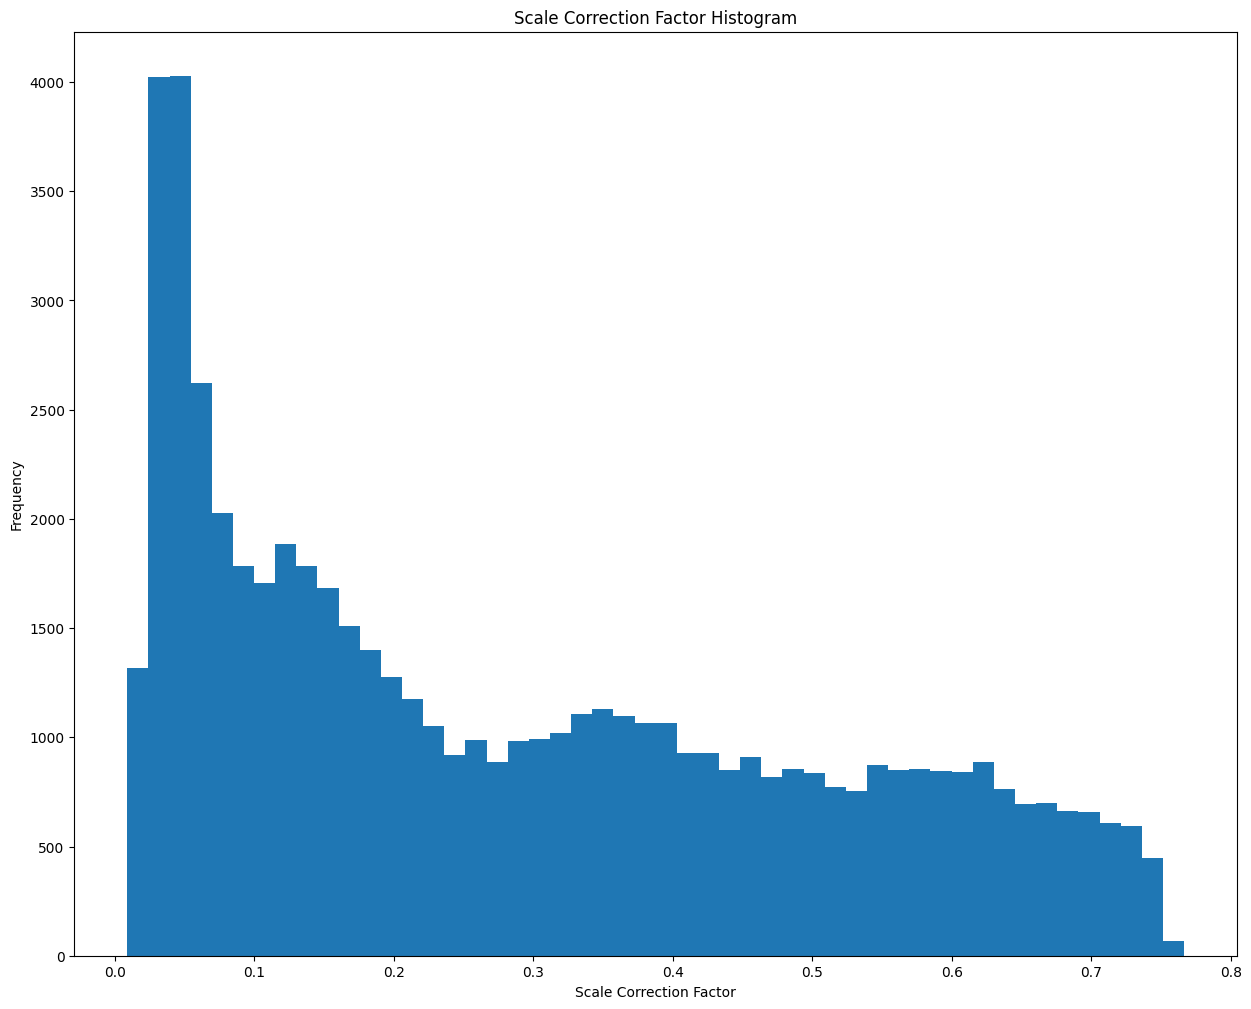

In [111]:
scale_correction_factor = WS.scale_correction_factor

# show histogram of scale_correction_factor
plt.hist(scale_correction_factor.cpu().detach().numpy(), bins=50)
plt.title("Scale Correction Factor Histogram")
plt.xlabel("Scale Correction Factor")
plt.ylabel("Frequency")
plt.show()

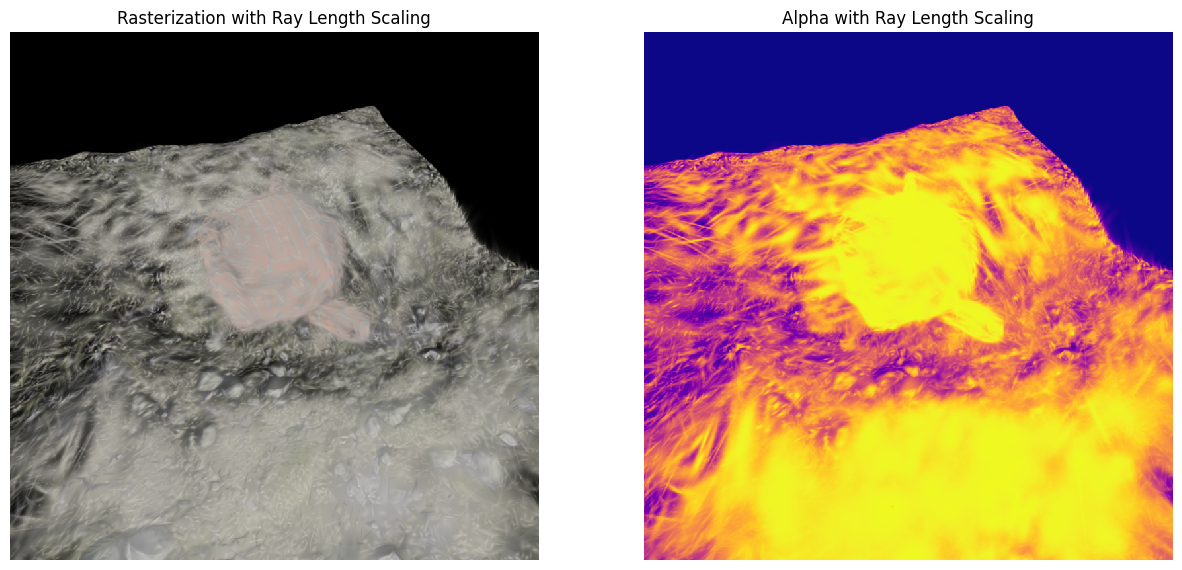

In [112]:
t_scales_ray = WS.transform_scales(
    method_transform_scales="ray_length",
    scale_correct_space="real"
)

render_ray, alpha_ray, _ = rasterization(
    t_means,
    t_quats,
    t_scales_ray,
    opacities,
    colors,
    worldtocam,
    K,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
render_ray = render_ray.squeeze().cpu().detach().numpy()
alpha_ray = alpha_ray.squeeze().cpu().detach().numpy()
fig, axes = plt.subplots(1, 2)
axes[0].imshow(render_ray)
axes[0].axis('off')
axes[0].set_title("Rasterization with Ray Length Scaling")
axes[1].imshow(alpha_ray, cmap='plasma')
axes[1].axis('off')
axes[1].set_title("Alpha with Ray Length Scaling")
plt.show()


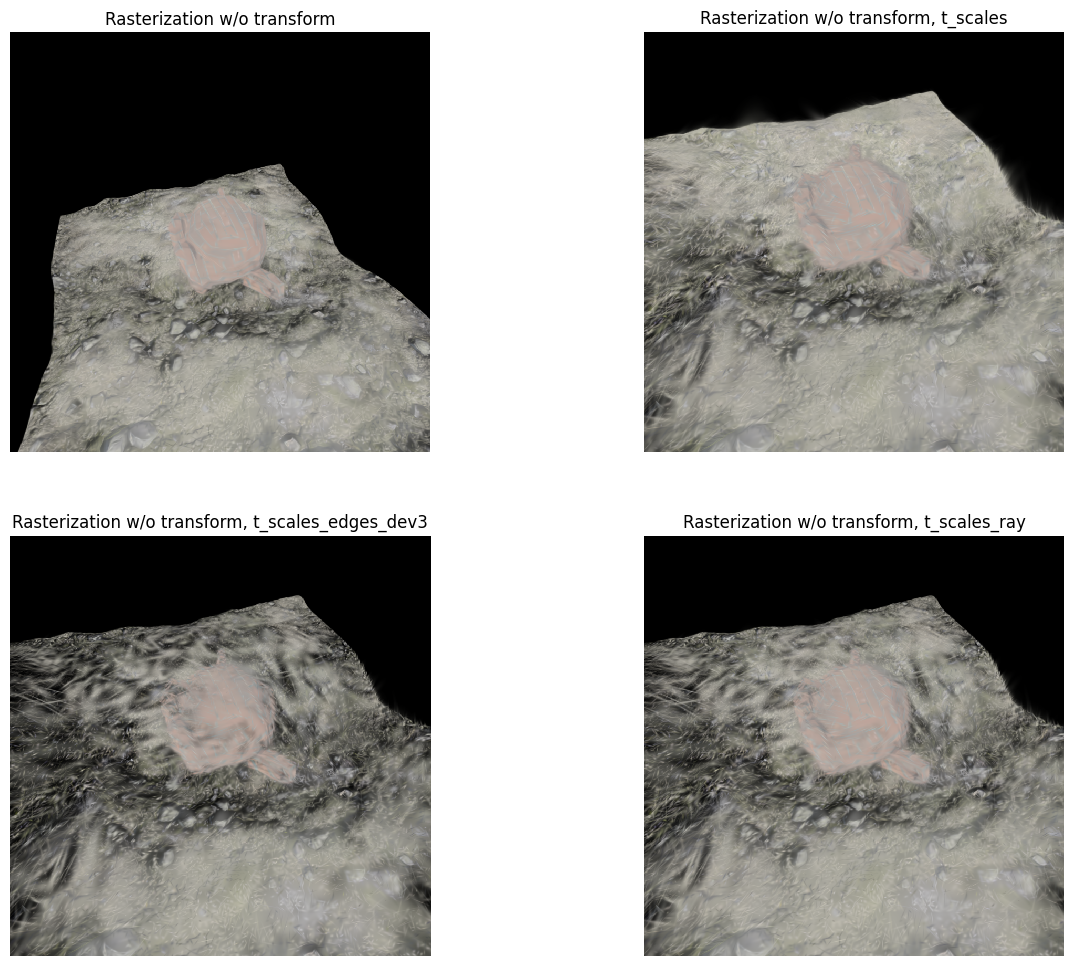

In [113]:
render_wo_t_scales, _, _ = rasterization(
    t_means,
    t_quats,
    scales,
    opacities,
    colors,
    worldtocam,
    K,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
render_wo_t_scales = render_wo_t_scales.squeeze().cpu().detach().numpy()

remder_edges_dev3, _, _ = rasterization(
    t_means,
    t_quats,
    t_scales_edges_dev3,
    opacities,
    colors,
    worldtocam,
    K,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
remder_edges_dev3 = remder_edges_dev3.squeeze().cpu().detach().numpy()

fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

# show render_wo, wo t_scales, t_scales_edges_dev3, t_scales_ray
axes[0].imshow(render_wo)
axes[0].axis('off')
axes[0].set_title("Rasterization w/o transform")
axes[1].imshow(render_wo_t_scales)
axes[1].axis('off')
axes[1].set_title("Rasterization w/o transform, t_scales")
axes[2].imshow(remder_edges_dev3)
axes[2].axis('off')
axes[2].set_title("Rasterization w/o transform, t_scales_edges_dev3")
axes[3].imshow(render_ray)
axes[3].axis('off')
axes[3].set_title("Rasterization w/o transform, t_scales_ray")
plt.show()


In [114]:
print("t_scales_edges_dev3", t_scales_edges_dev3[:10])
print("t_scales_edges_dev2", t_scales_ray[:10])

t_scales_edges_dev3 tensor([[0.0480, 0.0089, 0.0385],
        [0.0338, 0.1082, 0.0065],
        [0.1772, 0.0161, 0.0310],
        [0.0555, 0.0254, 0.0988],
        [0.0137, 0.0062, 0.1275],
        [0.0151, 0.0323, 0.0684],
        [0.0958, 0.0014, 0.0458],
        [0.0206, 0.0238, 0.0995],
        [0.1315, 0.0461, 0.0184],
        [0.1795, 0.0348, 0.0142]], device='cuda:0')
t_scales_edges_dev2 tensor([[0.0618, 0.0114, 0.0496],
        [0.0380, 0.1218, 0.0073],
        [0.2035, 0.0185, 0.0356],
        [0.0641, 0.0293, 0.1141],
        [0.0170, 0.0077, 0.1584],
        [0.0173, 0.0371, 0.0786],
        [0.1067, 0.0016, 0.0510],
        [0.0271, 0.0313, 0.1308],
        [0.1500, 0.0527, 0.0209],
        [0.2047, 0.0397, 0.0162]], device='cuda:0')


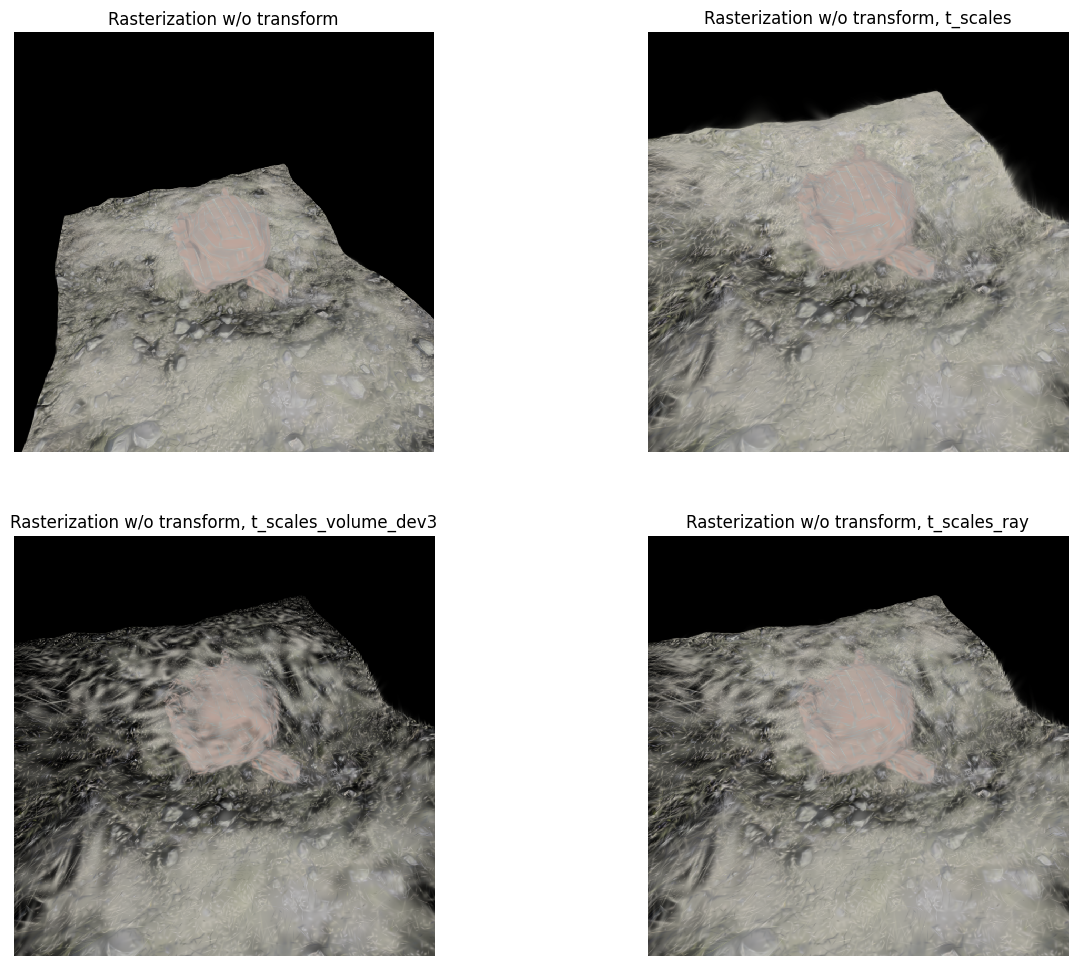

In [115]:
render_wo_t_scales, _, _ = rasterization(
    t_means,
    t_quats,
    scales,
    opacities,
    colors,
    worldtocam,
    K,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
render_wo_t_scales = render_wo_t_scales.squeeze().cpu().detach().numpy()

render_volume_dev3, _, _ = rasterization(
    t_means,
    t_quats,
    t_scales_volume_dev3,
    opacities,
    colors,
    worldtocam,
    K,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
render_volume_dev3 = render_volume_dev3.squeeze().detach().cpu().numpy()

fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

# show render_wo, wo t_scales, t_scales_edges_dev3, t_scales_ray
axes[0].imshow(render_wo)
axes[0].axis('off')
axes[0].set_title("Rasterization w/o transform")
axes[1].imshow(render_wo_t_scales)
axes[1].axis('off')
axes[1].set_title("Rasterization w/o transform, t_scales")
axes[2].imshow(render_volume_dev3)
axes[2].axis('off')
axes[2].set_title("Rasterization w/o transform, t_scales_volume_dev3")
axes[3].imshow(render_ray)
axes[3].axis('off')
axes[3].set_title("Rasterization w/o transform, t_scales_ray")
plt.show()
